# Portfolio Theory

Portfolio theory explains how combining assets can improve the relationship between return and risk.

Abbreviations used in this notebook:

- **MPT**: Modern Portfolio Theory.
- **GMV**: Global Minimum Variance portfolio.
- **E[R]**: Expected return.
- **SD**: Standard Deviation, used as volatility.

## 1. Intuition

The central insight of Modern Portfolio Theory is that portfolio risk depends not only on asset risk, but also on how assets move together. Diversification can reduce portfolio volatility when assets are imperfectly correlated.

The efficient frontier is the set of portfolios that offer the highest expected return for each level of risk.

## 2. Mathematics

Portfolio expected return:

$$
E[R_p] = \sum_i w_i E[R_i]
$$

Portfolio variance:

$$
\sigma_p^2 = w^T \Sigma w
$$

Portfolio volatility:

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

Weights constraint:

$$
\sum_i w_i = 1
$$

## 3. Implementation

We generate random long-only portfolios and calculate expected annual return, volatility, and Sharpe ratio.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "03_portfolio_management" / "portfolio_utils.py"
spec = importlib.util.spec_from_file_location("portfolio_utils", helper_path)
portfolio_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(portfolio_utils)

plt.style.use("seaborn-v0_8-whitegrid")

returns = portfolio_utils.generate_synthetic_returns(periods=504, seed=321)
prices = portfolio_utils.returns_to_prices(returns)
assets = returns.columns.tolist()

expected_returns = portfolio_utils.annualized_return(returns)
covariance = returns.cov() * 252
weights = portfolio_utils.random_weights(len(assets), n_portfolios=8_000, seed=7)

portfolio_rows = []
for weight in weights:
    ret = portfolio_utils.portfolio_return(weight, expected_returns)
    vol = portfolio_utils.portfolio_volatility(weight, covariance)
    portfolio_rows.append({"return": ret, "volatility": vol, "sharpe": portfolio_utils.sharpe_ratio(ret, vol, risk_free_rate=0.015), **dict(zip(assets, weight))})

frontier = pd.DataFrame(portfolio_rows)
frontier.head()

,return,volatility,sharpe,Global Equity,Swiss Equity,Bonds,Real Estate,Commodities
0,0.048403,0.085442,0.390939,0.221401,0.317781,0.274738,0.079765,0.106315
1,0.041438,0.081928,0.322703,0.294617,0.001776,0.276969,0.268821,0.157817
2,0.028583,0.092319,0.147137,0.169676,0.155898,0.142708,0.249210,0.282509
3,0.031526,0.087295,0.189311,0.140027,0.251847,0.200532,0.157402,0.250192
4,0.048321,0.060048,0.554895,0.201660,0.150056,0.573709,0.041156,0.033418


In [2]:
max_sharpe = frontier.loc[frontier["sharpe"].idxmax()]
min_vol = frontier.loc[frontier["volatility"].idxmin()]

pd.DataFrame({
    "max_sharpe": max_sharpe[["return", "volatility", "sharpe"]],
    "min_volatility": min_vol[["return", "volatility", "sharpe"]],
}).round(4)

,max_sharpe,min_volatility
return,0.0505,0.0361
volatility,0.0560,0.0491
sharpe,0.6344,0.4286


## 4. Visualization

A random frontier cloud shows the trade-off between risk and return across many possible portfolios.

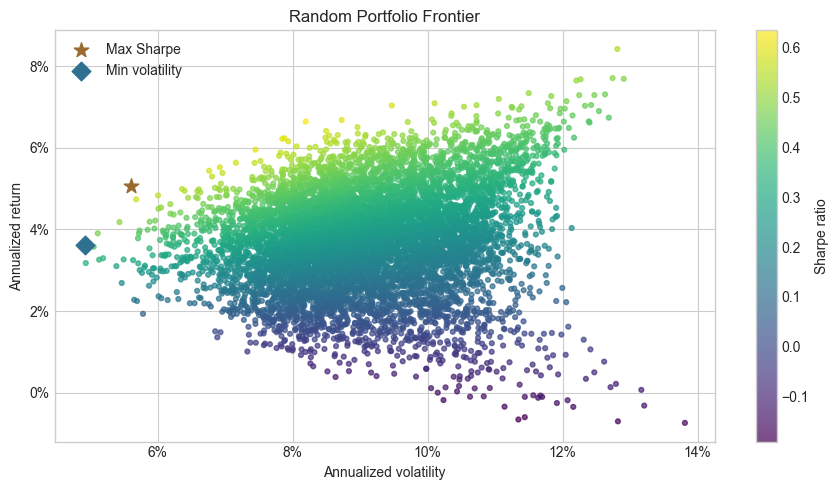

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(frontier["volatility"], frontier["return"], c=frontier["sharpe"], cmap="viridis", s=12, alpha=0.7)
ax.scatter(max_sharpe["volatility"], max_sharpe["return"], color="#9a6b2f", s=120, marker="*", label="Max Sharpe")
ax.scatter(min_vol["volatility"], min_vol["return"], color="#2f6f8f", s=90, marker="D", label="Min volatility")
ax.set_title("Random Portfolio Frontier")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized return")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
fig.colorbar(scatter, ax=ax, label="Sharpe ratio")
plt.tight_layout()
plt.show()

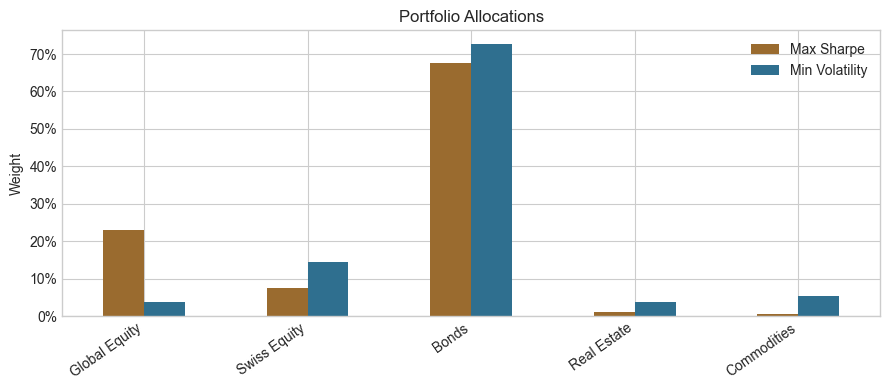

In [4]:
allocation = pd.DataFrame({
    "Max Sharpe": max_sharpe[assets],
    "Min Volatility": min_vol[assets],
})

allocation.plot(kind="bar", figsize=(9, 4), color=["#9a6b2f", "#2f6f8f"])
plt.title("Portfolio Allocations")
plt.ylabel("Weight")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 5. Application

Portfolio theory is used to compare allocation choices before committing capital. It helps investors understand whether risk is being rewarded and whether diversification is doing useful work.

In [5]:
equal_weights = np.repeat(1 / len(assets), len(assets))
equal_summary = pd.Series({
    "return": portfolio_utils.portfolio_return(equal_weights, expected_returns),
    "volatility": portfolio_utils.portfolio_volatility(equal_weights, covariance),
})
equal_summary["sharpe"] = portfolio_utils.sharpe_ratio(equal_summary["return"], equal_summary["volatility"], 0.015)

equal_summary.to_frame("equal_weight")

,equal_weight
return,0.037353
volatility,0.087052
sharpe,0.256776


## 6. Reflection

- Diversification depends on correlation, not just number of holdings.
- The efficient frontier is a map of trade-offs.
- The maximum Sharpe portfolio is sensitive to expected return estimates.
- The minimum volatility portfolio can be more stable but may sacrifice upside.

Questions to answer after running the notebook:

1. Which asset dominates the minimum-volatility portfolio?
2. Why is the maximum Sharpe portfolio estimation-sensitive?
3. How does the equal-weight portfolio compare?
4. What real-world constraints would you add?